# STEP 3: Automated VIF Pruning (Multicollinearity Removal)
### SpaceFund Realty (SFR) Aerospace Ratings Engine — Capstone Project

**Owner:** Sikiru Mustapha

---
**Pipeline position:** `Data Cleaning & Splits → Outlier Detection → OLS Diagnostics → VIF Pruning → Regularization → XGBoost/SHAP`

---
This notebook covers the VIF Pruning box. It reads `train_no_outliers.csv` (from `02_outlier_detection_diagnostics.ipynb`) and produces `train_vif_pruned_features.csv`, a list of the surviving predictors.

## 3.1 — Mount Google Drive & Load the Outlier-Cleaned Training Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

PROJECT_FOLDER = "/content/drive/MyDrive/Gamma_Group_1"

train = pd.read_csv(f"{PROJECT_FOLDER}/train_no_outliers.csv")
print(f"Loaded {train.shape[0]} rows and {train.shape[1]} columns from Step 2's output.")
train.head()

Mounted at /content/drive
Loaded 140 rows and 32 columns from Step 2's output.


,Company,SFR,Payload (kg),Launch Cost ($M),Price ($/kg),Funding ($M),Launch Class,Orbit Altitude,Tech Type,Country,...,TT_Balloon,TT_Other,TT_Plane,TT_Rocket,TT_Spaceplane,Funding_Missing,log_Payload (kg),log_Launch Cost ($M),log_Price ($/kg),log_Funding_num
0,Dark,1,200,5.0,25000,NaN,Small,LEO,"Plane, Rocket",France,...,0,0,1,1,0,1,5.303305,1.791759,10.126671,2.697663
1,TiSPACE,3,390,0.0,0,NaN,Small,LEO,Rocket,Taiwan,...,0,0,0,1,0,1,5.968708,0.000000,0.000000,2.697663
2,Space Engine Systems,4,5500,0.0,0,22.00,Medium,LEO,Spaceplane,Canada,...,0,0,0,0,1,0,8.612685,0.000000,0.000000,3.135494
3,Skyroot Aerospace,5,720,0.0,0,68.00,Small,LEO,Rocket,India,...,0,0,0,1,0,0,6.580639,0.000000,0.000000,4.234107
4,Celestia Aerospace,2,16,0.2,12500,NaN,Small,LEO,"Plane, Rocket",Spain,...,0,0,1,1,0,1,2.833213,0.182322,9.433564,2.697663


## 3.2 — Rebuild the Design Matrix


In [2]:
continuous_cols = ["Payload (kg)", "Launch Cost ($M)", "Price ($/kg)", "Funding_num"]
skew_vals = train[continuous_cols].skew()

log_transformed_cols = []
for col in continuous_cols:
    if abs(skew_vals[col]) > 1:
        train[f"log_{col}"] = np.log1p(train[col])
        log_transformed_cols.append(f"log_{col}")

dummy_cols = pd.get_dummies(train[["Country_Grouped", "Funding_Type"]], drop_first=True, dtype=int)
multihot_cols = [c for c in train.columns if c.startswith(("LC_", "OA_", "TT_"))]

import statsmodels.api as sm

X = pd.concat(
    [train[log_transformed_cols], dummy_cols, train[multihot_cols], train[["Funding_Missing"]]],
    axis=1,
).astype(float)
X = sm.add_constant(X)

print(f"Design matrix rebuilt: {X.shape[0]} rows, {X.shape[1]} columns (including intercept).")

Design matrix rebuilt: 140 rows, 25 columns (including intercept).


## 3.3 — Compute Initial VIF for Every Predictor


In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")  # suppresses expected divide-by-zero warnings from infinite VIFs

def compute_vif(design_matrix):
    """
    Computes the VIF for every column in a design matrix (including the constant).
    Returns a DataFrame sorted by VIF descending -- the worst offenders on top.
    """
    vif_table = pd.DataFrame()
    vif_table["feature"] = design_matrix.columns
    vif_table["VIF"] = [
        variance_inflation_factor(design_matrix.values, i)
        for i in range(design_matrix.shape[1])
    ]
    return vif_table.sort_values("VIF", ascending=False).reset_index(drop=True)

initial_vif = compute_vif(X)
print(initial_vif.to_string())

                           feature         VIF
0              Funding_Type_Public         inf
1                  Funding_Missing         inf
2             Funding_Type_Unknown         inf
3                            const  137.441568
4                        TT_Rocket   10.030664
5                    OA_Suborbital    7.003868
6                           OA_LEO    6.612753
7                    TT_Spaceplane    6.508046
8    Country_Grouped_United States    5.090072
9                         TT_Other    5.008117
10           Country_Grouped_Other    4.662719
11                        LC_Small    3.148622
12                log_Payload (kg)    3.021512
13                       LC_Medium    2.798692
14            log_Launch Cost ($M)    2.617571
15                      LC_Tourism    2.591739
16  Country_Grouped_United Kingdom    2.394872
17                        LC_Heavy    2.300636
18                log_Price ($/kg)    2.094597
19          Country_Grouped_France    1.915757
20           

## 3.4 — Automated VIF Pruning Loop


In [4]:
def vif_pruning_loop(design_matrix, threshold=5.0):
    """
    Repeatedly removes the single worst-offending predictor (by VIF) until
    every remaining predictor is at or below the given threshold.
    Zero-variance columns are removed first, since VIF cannot be meaningfully
    computed for them.
    Returns the pruned design matrix and a step-by-step log of what was
    removed and why (for transparency / the technical report).
    """
    design_matrix = design_matrix.copy()
    removal_log = []
    step_number = 0

    while True:
        step_number += 1

        # Step A: remove any zero-variance columns (excluding the intercept)
        zero_variance_cols = [
            col for col in design_matrix.columns
            if col != "const" and design_matrix[col].nunique() <= 1
        ]
        if zero_variance_cols:
            for col in zero_variance_cols:
                removal_log.append({
                    "step": step_number,
                    "feature_removed": col,
                    "reason": "zero variance (no remaining information)",
                })
            design_matrix = design_matrix.drop(columns=zero_variance_cols)
            continue  # re-check from the top after removing zero-variance columns

        # Step B: compute VIF for everything except the intercept
        vif_table = compute_vif(design_matrix)
        candidates = vif_table[vif_table["feature"] != "const"].reset_index(drop=True)

        worst_offender = candidates.loc[candidates["VIF"].idxmax()]

        # Step C: stop if even the worst remaining predictor is under threshold
        if worst_offender["VIF"] <= threshold:
            break

        # Step D: otherwise, drop the single worst predictor and loop again
        removal_log.append({
            "step": step_number,
            "feature_removed": worst_offender["feature"],
            "reason": f"VIF = {worst_offender['VIF']:.2f} (exceeds threshold of {threshold})",
        })
        design_matrix = design_matrix.drop(columns=[worst_offender["feature"]])

    return design_matrix, removal_log


X_pruned, removal_log = vif_pruning_loop(X, threshold=5.0)

print(f"Started with {X.shape[1] - 1} predictors (excluding intercept).")
print(f"Ended with {X_pruned.shape[1] - 1} predictors after pruning.")
print(f"\n{len(removal_log)} columns removed, in order:\n")
for entry in removal_log:
    print(f"  Step {entry['step']}: removed '{entry['feature_removed']}' -- {entry['reason']}")

Started with 24 predictors (excluding intercept).
Ended with 19 predictors after pruning.

5 columns removed, in order:

  Step 1: removed 'OA_Lunar' -- zero variance (no remaining information)
  Step 2: removed 'Funding_Type_Public' -- VIF = inf (exceeds threshold of 5.0)
  Step 3: removed 'Funding_Type_Unknown' -- VIF = 10.99 (exceeds threshold of 5.0)
  Step 4: removed 'TT_Rocket' -- VIF = 10.03 (exceeds threshold of 5.0)
  Step 5: removed 'OA_Suborbital' -- VIF = 7.00 (exceeds threshold of 5.0)


## 3.5 — Confirm the Final Model Is Clean


In [5]:
final_vif = compute_vif(X_pruned)
print(final_vif.to_string())

max_vif_excluding_const = final_vif[final_vif["feature"] != "const"]["VIF"].max()
print(f"\nMax VIF among remaining predictors: {max_vif_excluding_const:.2f}")
print("PASS: all remaining predictors are below the 5.0 threshold." if max_vif_excluding_const <= 5.0
      else "WARNING: something above threshold remains -- re-check the loop.")

                           feature        VIF
0                            const  53.115838
1    Country_Grouped_United States   4.794936
2            Country_Grouped_Other   4.465829
3                         LC_Small   2.951252
4                 log_Payload (kg)   2.943092
5                        LC_Medium   2.372685
6   Country_Grouped_United Kingdom   2.344967
7             log_Launch Cost ($M)   2.337940
8                         LC_Heavy   2.229241
9                       LC_Tourism   2.148315
10                log_Price ($/kg)   2.067590
11          Country_Grouped_France   1.751086
12           Country_Grouped_India   1.703036
13                      TT_Balloon   1.586083
14                   TT_Spaceplane   1.477009
15                          OA_LEO   1.448345
16                        TT_Other   1.421823
17                 log_Funding_num   1.362207
18                 Funding_Missing   1.219373
19                        TT_Plane   1.172872

Max VIF among remaining predictor

## 3.6 — Refit the Model on the Pruned Predictors & Compare


In [6]:
y = train["SFR"].astype(float)

model_before_pruning = sm.OLS(y, X).fit()
model_after_pruning = sm.OLS(y, X_pruned).fit()

print(f"R-squared BEFORE VIF pruning: {model_before_pruning.rsquared:.4f} ({X.shape[1]-1} predictors)")
print(f"R-squared AFTER VIF pruning:  {model_after_pruning.rsquared:.4f} ({X_pruned.shape[1]-1} predictors)")
print(f"\nChange in R-squared: {model_after_pruning.rsquared - model_before_pruning.rsquared:+.4f}")
print("\nFinal surviving predictors:")
for col in X_pruned.columns:
    if col != "const":
        print(f"  - {col}")

R-squared BEFORE VIF pruning: 0.7495 (24 predictors)
R-squared AFTER VIF pruning:  0.6023 (19 predictors)

Change in R-squared: -0.1472

Final surviving predictors:
  - log_Payload (kg)
  - log_Launch Cost ($M)
  - log_Price ($/kg)
  - log_Funding_num
  - Country_Grouped_France
  - Country_Grouped_India
  - Country_Grouped_Other
  - Country_Grouped_United Kingdom
  - Country_Grouped_United States
  - LC_Heavy
  - LC_Medium
  - LC_Small
  - LC_Tourism
  - OA_LEO
  - TT_Balloon
  - TT_Other
  - TT_Plane
  - TT_Spaceplane
  - Funding_Missing


## 3.7 — Visual Summary: Before & After Pruning


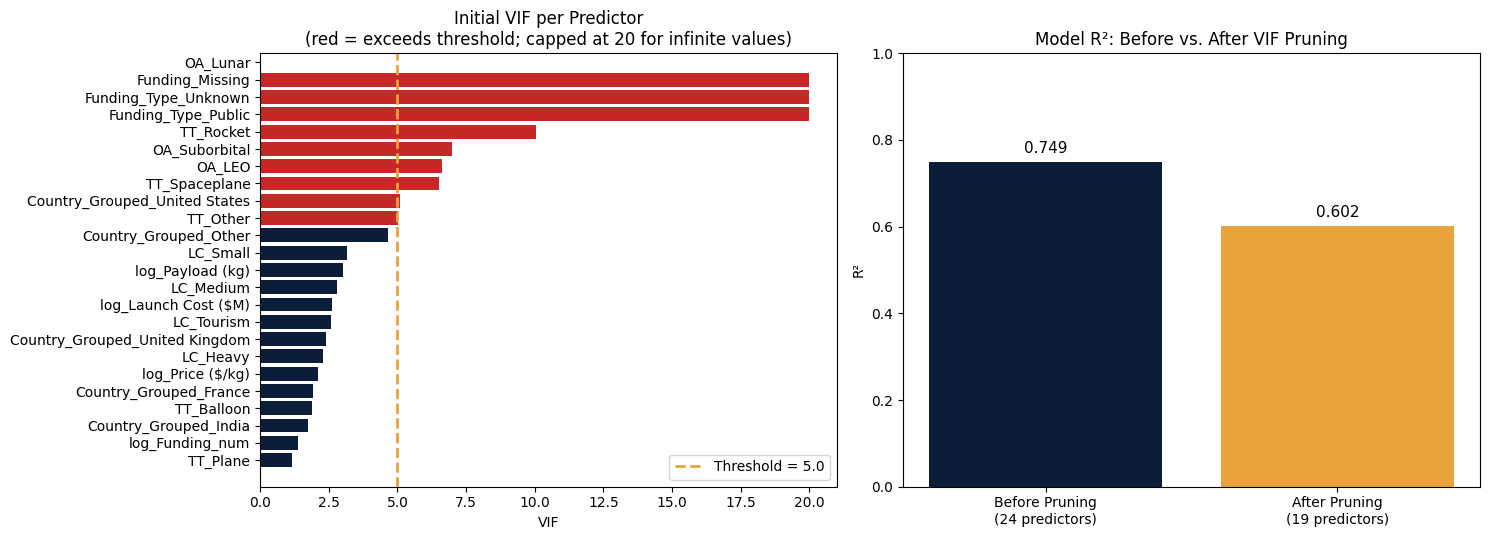

Saved: step3_visual_summary.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# --- Chart 1: Initial VIF, sorted, threshold line, capped for readability ---
plot_vif = initial_vif[initial_vif["feature"] != "const"].copy()
plot_vif["VIF_capped"] = plot_vif["VIF"].clip(upper=20)  # cap infinities/huge values for a readable chart
plot_vif = plot_vif.sort_values("VIF_capped", ascending=True)
bar_colors_vif = ["#C62828" if v > 5.0 or v == 20 else "#0B1D3A" for v in plot_vif["VIF_capped"]]
axes[0].barh(plot_vif["feature"], plot_vif["VIF_capped"], color=bar_colors_vif)
axes[0].axvline(5.0, color="#E8A33D", linestyle="--", linewidth=2, label="Threshold = 5.0")
axes[0].set_title("Initial VIF per Predictor\n(red = exceeds threshold; capped at 20 for infinite values)")
axes[0].set_xlabel("VIF")
axes[0].legend()

# --- Chart 2: R-squared before/after pruning ---
r2_values = [model_before_pruning.rsquared, model_after_pruning.rsquared]
bars = axes[1].bar(["Before Pruning\n(24 predictors)", "After Pruning\n(19 predictors)"], r2_values,
                    color=["#0B1D3A", "#E8A33D"])
axes[1].set_title("Model R\u00b2: Before vs. After VIF Pruning")
axes[1].set_ylabel("R\u00b2")
axes[1].set_ylim(0, 1)
for bar, val in zip(bars, r2_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig(f"{PROJECT_FOLDER}/step3_visual_summary.png", dpi=150)
plt.show()

print("Saved: step3_visual_summary.png")

## 3.8 — Save the Pruned Feature List & Design Matrix to Google Drive


In [8]:
# Combine the pruned predictors with the target variable for easy downstream use
final_design_matrix = X_pruned.copy()
final_design_matrix["SFR"] = y.values

final_design_matrix.to_csv(f"{PROJECT_FOLDER}/train_vif_pruned_design_matrix.csv", index=False)

removal_log_df = pd.DataFrame(removal_log)
removal_log_df.to_csv(f"{PROJECT_FOLDER}/vif_pruning_log.csv", index=False)

print(f"Saved to Google Drive folder: {PROJECT_FOLDER}")
print("  - train_vif_pruned_design_matrix.csv")
print("  - vif_pruning_log.csv")
print(f"\nStep 3 complete: {len(removal_log)} redundant predictors removed, "
      f"{X_pruned.shape[1]-1} clean predictors remain, all with VIF <= 5.0.")

Saved to Google Drive folder: /content/drive/MyDrive/Gamma_Group_1
  - train_vif_pruned_design_matrix.csv
  - vif_pruning_log.csv

Step 3 complete: 5 redundant predictors removed, 19 clean predictors remain, all with VIF <= 5.0.
